# Analysis of fission yield sampling using SANDY

This document explains step‑by‑step how to:

- load fission‑yield data,
- generate perturbed samples
- analyze correlations
- compute mass yields
- compare uncertainty with/without covariance.

In [1]:
import sandy
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import pandas as pd

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


We load:

- `sandy` → nuclear data processing and sampling
- `seaborn` / `matplotlib` → visualization
- `pandas` → data handling

## 1. Read U‑235 Fission Yields from JEFF‑4.0

Load fission yields data grouped by:

 - `MAT`: nuclide identifier
 - `MT`: 454=independent yields, 459=cumulative yields
 - `ZAM`: fissioning nuclide
 - `E`: fission energy → 0.0253 eV (thermal), 400 keV (fast), 14 MeV (high-energy)
 - `ZAP`: fission product ID
 - `FY`: best estimate
 - `DFY`: uncertainty

In [2]:
tape = sandy.get_endf6_file("jeff_40", "nfpy", 922350)
fy = sandy.Fy.from_endf6(tape)
fy

       MAT   MT     ZAM     ZAP             E            FY           DFY
0     9228  454  922350   10010  2.530000e-02  1.710000e-05  2.950000e-06
1     9228  454  922350   10020  2.530000e-02  8.400000e-06  2.440000e-06
2     9228  454  922350   10030  2.530000e-02  1.080000e-04  5.860000e-06
3     9228  454  922350   20030  2.530000e-02  1.000000e-14  1.000000e-14
4     9228  454  922350   20040  2.530000e-02  1.700000e-03  8.140000e-05
...    ...  ...     ...     ...           ...           ...           ...
6249  9228  459  922350  771940  1.400000e+07  3.316300e-12  3.446800e-12
6250  9228  459  922350  771950  1.400000e+07  1.405700e-12  1.490400e-12
6251  9228  459  922350  771951  1.400000e+07  1.353800e-12  1.510600e-12
6252  9228  459  922350  781940  1.400000e+07  3.316300e-12  3.446800e-12
6253  9228  459  922350  781950  1.400000e+07  2.691800e-12  2.639300e-12

[6254 rows x 7 columns]

## 2. Generate perturbation coefficients

### 2.1 Case without fission yield covariance matrix

In [3]:
smp_size = 1000
smps = tape.get_perturbations(smp_size, write=False, verbose=True)

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | using diagonal matrix (only variance)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | covariance matrix size=(983, 983)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | sampling with SMP size=1000 via sampling(seed=302170169826399522463380996065107427552, {})
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=4.00000

Extract only the **thermal FY** sample matrix:

In [4]:
thermal_data = smps["IFY"].data.query("E==0.0253").droplevel(["ZAM", "E"])
thermal_data

SMP,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
ZAP,,,,,,,,,,,,,,,,,,,,,
10010,1.190621,1.078465,0.936584,0.924666,0.724199,0.823206,0.724743,1.333854,1.178512,1.443726,...,1.143242,1.187631,0.965076,0.826333,1.169008,0.914400,0.915074,1.029322,0.856084,1.300311
10020,0.709632,1.061611,0.527082,1.281325,0.697997,0.707655,1.022983,1.102217,0.716791,0.818945,...,0.979674,0.916478,1.012943,1.616782,1.070012,1.147031,1.256053,0.992148,0.677147,0.795106
10030,0.981440,1.136105,1.035254,1.058683,1.011526,0.952979,0.999466,0.878812,0.969544,1.025858,...,1.022520,0.967455,1.061226,1.136045,1.027147,1.039258,1.116659,1.091067,1.098765,0.988520
20030,2.933762,0.298299,1.487127,0.916273,0.267823,0.196351,0.921744,0.143899,1.741185,0.360973,...,1.916251,0.663105,0.676046,0.634746,1.501258,1.188853,2.191827,0.286972,0.793922,0.541412
20040,0.951317,0.991835,0.994869,1.024248,1.002894,0.996900,0.974607,1.043731,1.037959,1.036140,...,0.904742,0.980638,0.970795,0.988135,0.962459,0.926704,1.072868,0.942895,0.944537,1.022737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701770,0.261862,0.132480,1.242049,1.152696,1.225781,0.567933,0.261175,0.227622,0.110202,6.178270,...,1.628718,0.341439,0.542191,1.236246,0.163319,1.306511,0.810091,2.401117,0.933261,0.343969
701771,0.768613,0.570737,0.165180,0.504781,1.726326,0.338530,0.563393,0.235871,1.385584,0.478441,...,0.601003,0.218104,0.298080,0.578480,0.611294,1.767850,1.109217,0.475913,1.374431,2.391489
711750,1.211180,1.064017,0.308164,0.813532,0.489442,0.223042,0.994847,0.699264,2.642424,0.587247,...,0.892683,2.449878,1.103946,1.797516,0.256207,1.373166,0.483834,0.361859,0.887631,1.902181


### 2.2 Case with fission yield covariance matrix (only for JEFF-4.0)

Covariance matrices are available for JEFF-4.0 only, and for the thermal fissioning systems of:

    - U-233
    - U-235
    - Pu-239
    - Pu-241

In [5]:
smp_size = 1000
smps_cov = tape.get_perturbations(smp_size, covariance=True, write=False, verbose=True)
thermal_data_cov = smps_cov["IFY"].data.query("E==0.0253").droplevel(["ZAM", "E"])

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | using JEFF-4.0 covariance matrix (with correlations) and fission yield data
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | covariance matrix size=(983, 983)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | sampling with SMP size=1000 via sampling(seed=40376687943646446419118838054656522765, {})
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | no explicit seed provided
get_pert

### 2.3 Compare correlation matrices

Extract sample correlations from sample matrices.

In [6]:
corr = thermal_data.T.corr()
corr_cov = thermal_data_cov.T.corr()

Plot the correlation matrix

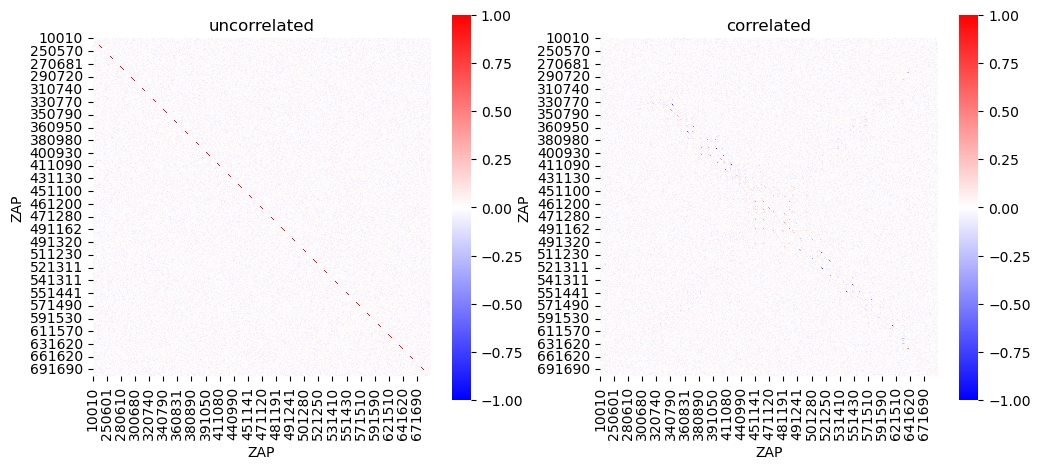

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

with_cov = corr
without_cov = corr_cov

# ZOOMED
# with_cov = corr.iloc[400:500, 400:500]
# without_cov = corr_cov.iloc[400:500, 400:500]

sns.heatmap(with_cov, cmap="bwr", vmin=-1, vmax=1, ax=axs[0], square=True)
sns.heatmap(without_cov, cmap="bwr", vmin=-1, vmax=1, ax=axs[1], square=True)
axs[0].set_title("uncorrelated")
axs[1].set_title("correlated");

## 3. Run Stochastic Sampling from Command-Line Arguments

This is identical to what you would run from command line, like:

```bash
python -m sandy.sampling U235_fy.jeff40 --samples 20 --processes 1
```

Twenty perturbed fission yield files are created.

In [8]:
command_line = "U235_fy.jeff40 --samples 20 --processes 1".split()
sandy.sampling.run(command_line)


========= SAMPLING CONFIGURATION =========
{ 'acer': False,
  'cov_energy_grid': 'csewg239',
  'file': 'U235_fy.jeff40',
  'from_perturbations': False,
  'fycov': False,
  'loglevel': 'info',
  'mf': [31, 33, 35],
  'mt33': 'all',
  'njoy': None,
  'no_verbose': False,
  'only_perturbations': False,
  'processes': 1,
  'samples': 20,
  'seed31': None,
  'seed33': None,
  'seed34': None,
  'seed35': None,
  'show_njoy': False,
  'temperatures': None,
  'tqdm': False}

sampling | processing file: 'U235_fy.jeff40'
sampling | ENDF-6 content: 1 MAT, 2 MF, 3 MT
sampling | detected MF=8/MT=454 (decay): using fission-yield path
########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.5300

Read the perturbed files.

In [9]:
data = {}
for i in range(20):
    tape = sandy.Endf6.from_file(f"fy_{i}")
    fy = sandy.Fy.from_endf6(tape)
    data[i] = fy

### 3.1 Propagate uncertainty to mass fission yields

For each sample of fission yields, let's calculate the so-called mass yields:

$Y(A) = \sum_{Z,M} Y(A, Z, M)$

summing all fission‑product yields for a given mass number A.

In [10]:
mass_yields = data[1].get_mass_yield(922350, 0.0253)
mass_yields

A
1      1.190177e-05
2      7.048633e-06
3      1.088256e-04
4      1.650410e-03
6      2.424807e-05
           ...     
173    6.068450e-12
174    1.668815e-12
175    9.060302e-12
176    4.545388e-12
177    1.199720e-13
Name: mass yield, Length: 134, dtype: float64

This is the common plot for fission yields!

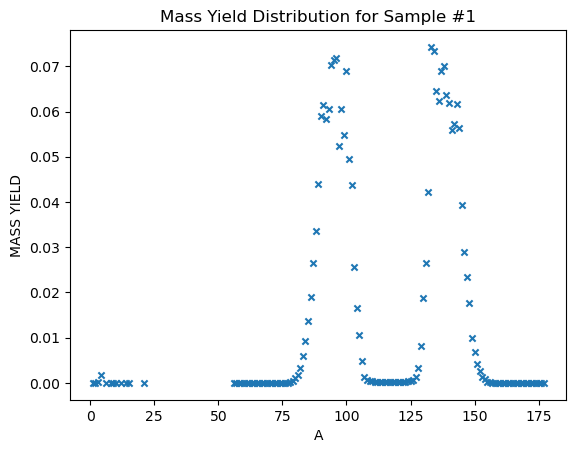

In [11]:
mass_yields.rename("MASS YIELD").reset_index().plot.scatter(x="A", y="MASS YIELD", marker="x")
plt.title("Mass Yield Distribution for Sample #1");

Let's put it in a loop and show the variability across samples in the graph.

Each color is one FY sample.

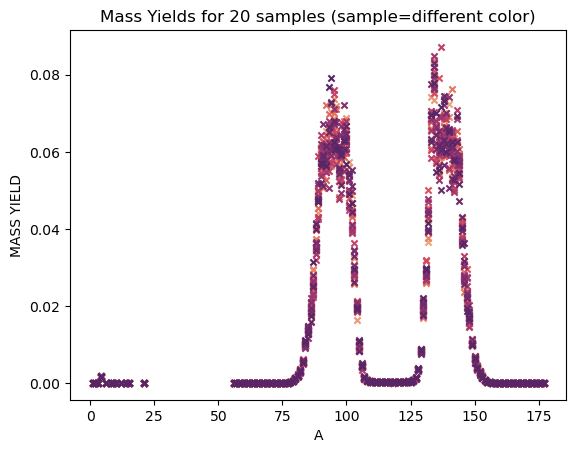

In [12]:
fig, ax = plt.subplots()

colors = sns.color_palette("flare", n_colors=len(data))

mass_yields = {}
for i, fy in data.items():
    mass_yields[i] = fy.get_mass_yield(922350, 0.0253)
    mass_yields[i].rename("MASS YIELD").reset_index().plot.scatter(x="A", y="MASS YIELD", marker="x", color=colors[i], ax=ax)

mass_yields = pd.DataFrame(mass_yields)
plt.title("Mass Yields for 20 samples (sample=different color)");

Calculate and plot the sample standard deviation.

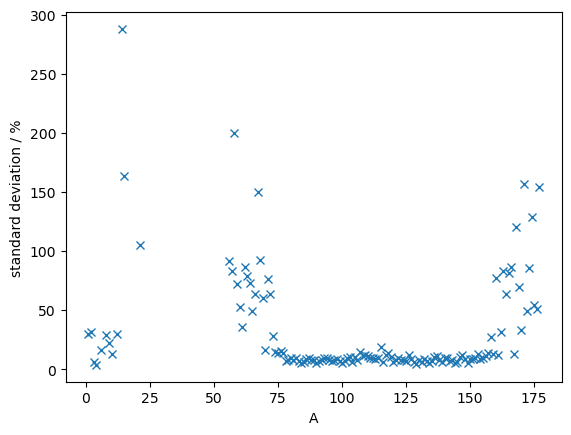

In [13]:
(mass_yields.std(axis=1) / mass_yields.mean(axis=1) * 100).plot(ls="none", marker="x")
plt.ylabel("standard deviation / %");

### 3.2 Propagate **covariance data** to mass fission yields

<div class="alert alert-block alert-info"> <b>⚠️</b> <p>Let's run again sandy with option `--fycov`</p>
</div>

For JEFF-4.0, the command line option `--fycov` allows sampling fission yields with covariance data for U-233, U-235, Pu-239 and Pu-241.

This works for thermal fissioning systems only.

Lets'run it!

> Watch out: the previous files are overwritten! If you still want them, move them or rename them.

In [14]:
sandy.sampling.run("U235_fy.jeff40 --samples 20 --processes 1 --fycov".split())


========= SAMPLING CONFIGURATION =========
{ 'acer': False,
  'cov_energy_grid': 'csewg239',
  'file': 'U235_fy.jeff40',
  'from_perturbations': False,
  'fycov': True,
  'loglevel': 'info',
  'mf': [31, 33, 35],
  'mt33': 'all',
  'njoy': None,
  'no_verbose': False,
  'only_perturbations': False,
  'processes': 1,
  'samples': 20,
  'seed31': None,
  'seed33': None,
  'seed34': None,
  'seed35': None,
  'show_njoy': False,
  'temperatures': None,
  'tqdm': False}

sampling | processing file: 'U235_fy.jeff40'
sampling | ENDF-6 content: 1 MAT, 2 MF, 3 MT
sampling | detected MF=8/MT=454 (decay): using fission-yield path
########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.53000

Let's get again the mass yields.

In [15]:
data = {}
for i in range(20):
    tape = sandy.Endf6.from_file(f"fy_{i}")
    fy = sandy.Fy.from_endf6(tape)
    data[i] = fy.get_mass_yield(922350, 0.0253)

mass_yields_cov = pd.DataFrame(data)

...and now compare the uncertainties.

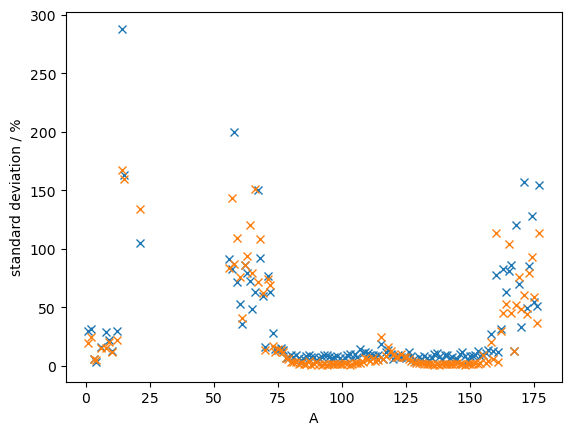

In [16]:
(mass_yields.std(axis=1) / mass_yields.mean(axis=1) * 100).plot(ls="none", marker="x")
(mass_yields_cov.std(axis=1) / mass_yields_cov.mean(axis=1) * 100).plot(ls="none", marker="x")
plt.ylabel("standard deviation / %");